# <h3 align="center">__Module 8 Activity__</h3>
# <h3 align="center">__Unnas Hussain__</h3>

# Problem 1: Support Vector Machines (SVM) - Understanding Margins & Decision Boundaries

A company is classifying emails as spam or not spam using an SVM classifier. The dataset consists of word frequency features extracted from emails. Your task is to visualize the decision boundary, experiment with the kernel type, and analyze how support vectors influence classification.

## Dataset
We will generate a synthetic dataset with two classes (spam and not spam) for visualization purposes.

## Code


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Generate synthetic dataset (2 features for visualization)
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# C values to animate through
C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0]

# Precompute grid for plotting
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

def plot_decision_boundary(model, X, y, title='SVM Decision Boundary'):
    """Plot decision boundary for a trained SVM model."""
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50)
    
    # Highlight support vectors
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=150, facecolors='none', edgecolors='green', linewidths=2)
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)

def create_svm_animation(kernel, C_values, X_train, y_train):
    """Create an animation showing SVM decision boundary as C changes."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    def animate(frame):
        ax.clear()
        C = C_values[frame]
        
        model = SVC(kernel=kernel, C=C)
        model.fit(X_train, y_train)
        
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=50)
        
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=150, facecolors='none', edgecolors='green', linewidths=2, label=f'Support Vectors (n={len(sv)})')
        
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_title(f'SVM Decision Boundary\nKernel: {kernel}, C={C}')
        ax.legend(loc='upper right')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
    
    anim = FuncAnimation(fig, animate, frames=len(C_values), interval=300, repeat=True)
    plt.close(fig)
    return anim

# Create and display animations for each kernel type
print("Linear Kernel Animation:")
anim_linear = create_svm_animation('linear', C_values, X_train, y_train)
display(HTML(anim_linear.to_jshtml()))

print("\nRBF Kernel Animation:")
anim_rbf = create_svm_animation('rbf', C_values, X_train, y_train)
display(HTML(anim_rbf.to_jshtml()))

print("\nPolynomial Kernel Animation:")
anim_poly = create_svm_animation('poly', C_values, X_train, y_train)
display(HTML(anim_poly.to_jshtml()))

Linear Kernel Animation:



RBF Kernel Animation:



Polynomial Kernel Animation:


## Reflection
1. How does the decision boundary change with different kernels?

`linear` seperates classes with a straight line. This dataset seems linearly seperable so this works and runs quickly. `rdf` creates a curved boundary and in this particular case it seems to create a boundary around one cluster of data, and the classification is more "inside that boundary vs outside. But non-linear relationships would easily be categorized with this more flexible method. `poly` is similar to linear but can more accuratly seperate non-linear data with higher degree polynomial functions defining the seperation boundary instead of a line.

2. What role do the support vectors play in defining the decision boundary?

Support vectors are the data poitns that lie closest to the decision boundary by some function (usually just Euclidean distance on a 2D plane). If you removed all other points, the boundaries should stay exactly the same.

3. Adjust the `C` parameter (try `C=0.1` vs. `C=10`). What effect does this have on the margin width and classification?

The lower the `C`, the wider margins you have between the data and the boundary (there are more support vectors that can be farther from the boundary if needed). This leads to some training points being misclassified, but the model will be faster and have better generalization of test data. The higher the `C`, the narrower the margin and less misclassifications 
will occur when training, but you risk overfitting and in theory you aren't going to be using all of your training data because a lot of it will end up being too far from the boundary.

4. If you have overlapping classes, which kernel type would likely perform best? Why?

RBF will perform the best with overlapping classes because it creates flexible non-linear boundaries that really key in on where there's gaps and dominate clusters. 

# Problem 2: Calculatin Decision Boundaries - Logistic Regression vs SVM

You are training a binary classifier to predict whether a customer will buy a product based on their income and age. The model must learn the decision boundary that separates the two groups.

## Code

Logistic Regression vs Linear SVM:


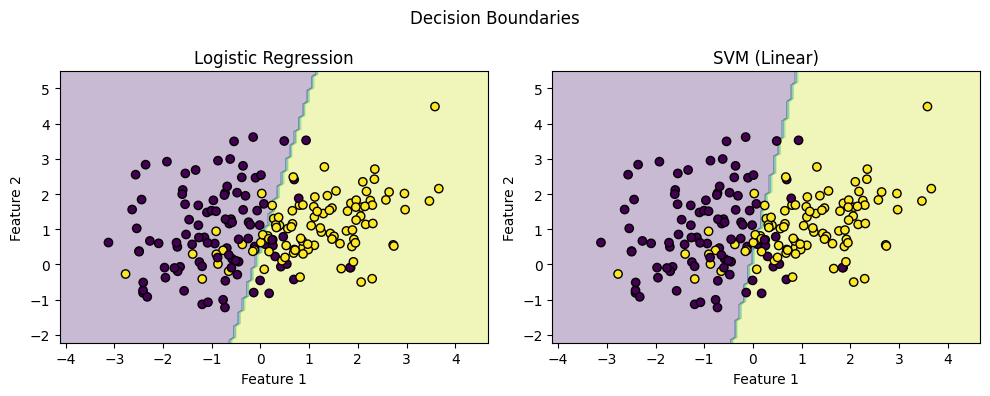


SVM with Different Kernels:


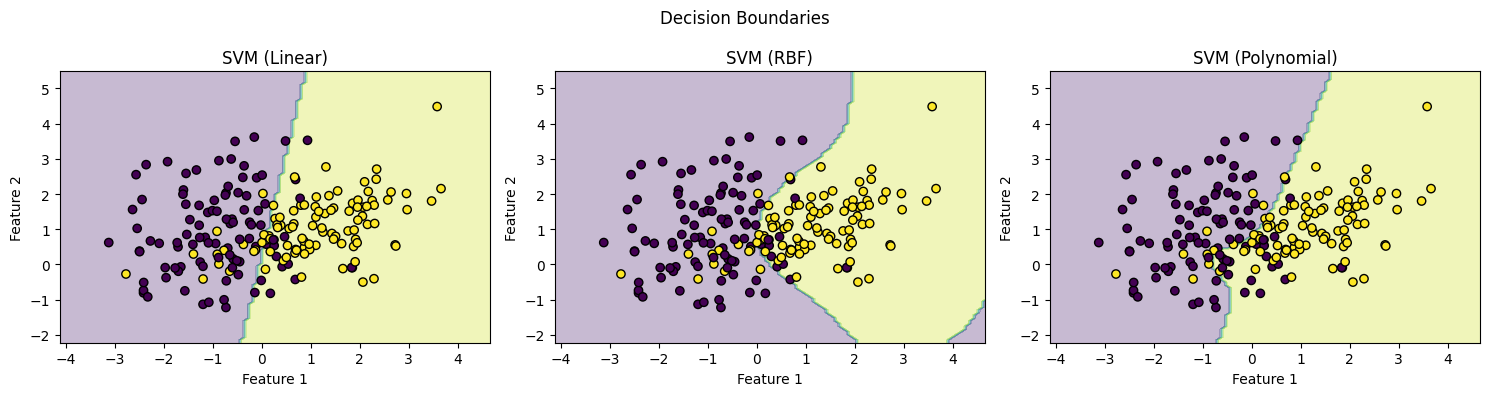


With Added Noise (mean=0, std=0.5):


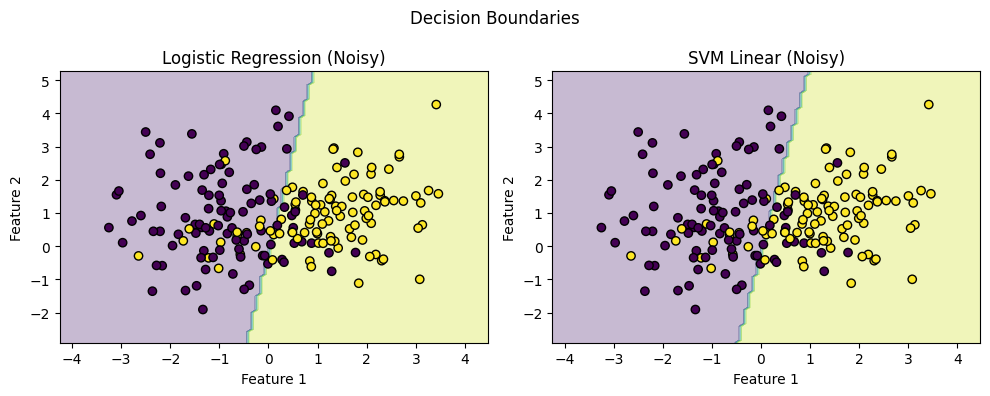

In [22]:
# Generate dataset with two features
X, y = make_classification(n_samples=200, n_features=2, n_classes=2, n_clusters_per_class=1, n_informative=2, n_redundant=0, random_state=42)

# Train Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X, y)

# Train SVM models with different kernels
svm_linear = SVC(kernel='linear')
svm_linear.fit(X, y)

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X, y)

svm_poly = SVC(kernel='poly')
svm_poly.fit(X, y)

# Function to plot decision boundaries
def plot_models(models, X, y, title="Decision Boundaries"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
    if n_models == 1:
        axes = [axes]

    for ax, (model, model_title) in zip(axes, models):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3)
        ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_title(model_title)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot Logistic Regression vs Linear SVM
print("Logistic Regression vs Linear SVM:")
plot_models([
    (log_reg, "Logistic Regression"),
    (svm_linear, "SVM (Linear)")
], X, y)

# Plot SVM with different kernels
print("\nSVM with Different Kernels:")
plot_models([
    (svm_linear, "SVM (Linear)"),
    (svm_rbf, "SVM (RBF)"),
    (svm_poly, "SVM (Polynomial)")
], X, y)

# Add noise and compare robustness
X_noisy = X + np.random.normal(0, 0.5, X.shape)

log_reg_noisy = LogisticRegression()
log_reg_noisy.fit(X_noisy, y)

svm_noisy = SVC(kernel='linear')
svm_noisy.fit(X_noisy, y)

print("\nWith Added Noise (mean=0, std=0.5):")
plot_models([
    (log_reg_noisy, "Logistic Regression (Noisy)"),
    (svm_noisy, "SVM Linear (Noisy)")
], X_noisy, y)

## Reflection
1. How do Logistic Regression and SVM differ in separating the two classes?

Logistic Regression finds the boundary that maximizes the likelihood of the training data given a probabilistic model. SVM finds the boundary that maximizes the margin between the two classes. In practice, the boundaries look very similar for linearly separable data, but the SVM boundary is specifically optimized to be equidistant from the nearest points of each class.

2. Logistic Regression models the probability of a class using a sigmoid function. How does this affect its decision boundary compared to SVM?

Logistic Regression outputs probabilities (0 to 1) and the decision boundary is where the probability equals 0.5. This means points far from the boundary have high confidence predictions. SVM finds the optimal separating hyperplane with more geometric/vector-based approaches instead of probabilites. The sigmoid in Logistic Regression makes it more sensitive to outliers since it tries to fit all points probabilistically in that normalized range, while SVM only cares about the support vectors near the boundary.

3. Modify the SVM model to use different kernel functions (RBF, Polynomial). How does the boundary change compared to the linear model?

RBF creates flexible boundaries that can wrap around clusters of data points. Polynomial creates curved boundaries based on polynomial degree, it can create more complex shapes than linear but is less flexible than RBF. This could be seen as linearly separable, but there is some overllaping data that RBF and Poly do more consistent jobs at adjusting to.

4. If a dataset has overlapping classes, which model is more likely to generalize well? Explain.

RBF kernel would likely generalize better for overlapping classes. The C parameter in SVM lets you control the tradeoff between margin width and misclassifications, so you can tune it to handle overlap gracefully and wrap around data clusters.

5. Try adding random noise to the dataset. Which model is more robust to noise, and why?

SVM tends to be more robust to noise because it only relies on support vectors (points near the boundary) to define the decision boundary/ Noisy points far from the boundary don't even get processed. Logistic Regression considers all points when fitting the model, so there is a risk that noise can significantly shift the boundary.

# Problem 3: Comparing Multiple Classification Models

A company wants to classify its customers into three segments based on their purchasing behavior:

- Class 0: Low-Value Customers
- Class 1: Mid-Value Customers
- Class 2: High-Value Customers

Using customer transaction data, we need to train multiple classification models and determine which performs best.

## Code

Original class distribution: [268 267 265]
After SMOTE: [268 268 268]

Model Comparison:
                      Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
        Logistic Regression     0.915   0.918624   0.915  0.914532 0.974876
              Random Forest     0.925   0.928110   0.925  0.924629 0.988244
                  SVM (RBF)     0.950   0.952910   0.950  0.949956 0.995873
Logistic Regression + SMOTE     0.915   0.918624   0.915  0.914532 0.974952
      Random Forest + SMOTE     0.930   0.933378   0.930  0.929360 0.986664
          SVM (RBF) + SMOTE     0.950   0.952910   0.950  0.949956 0.995230


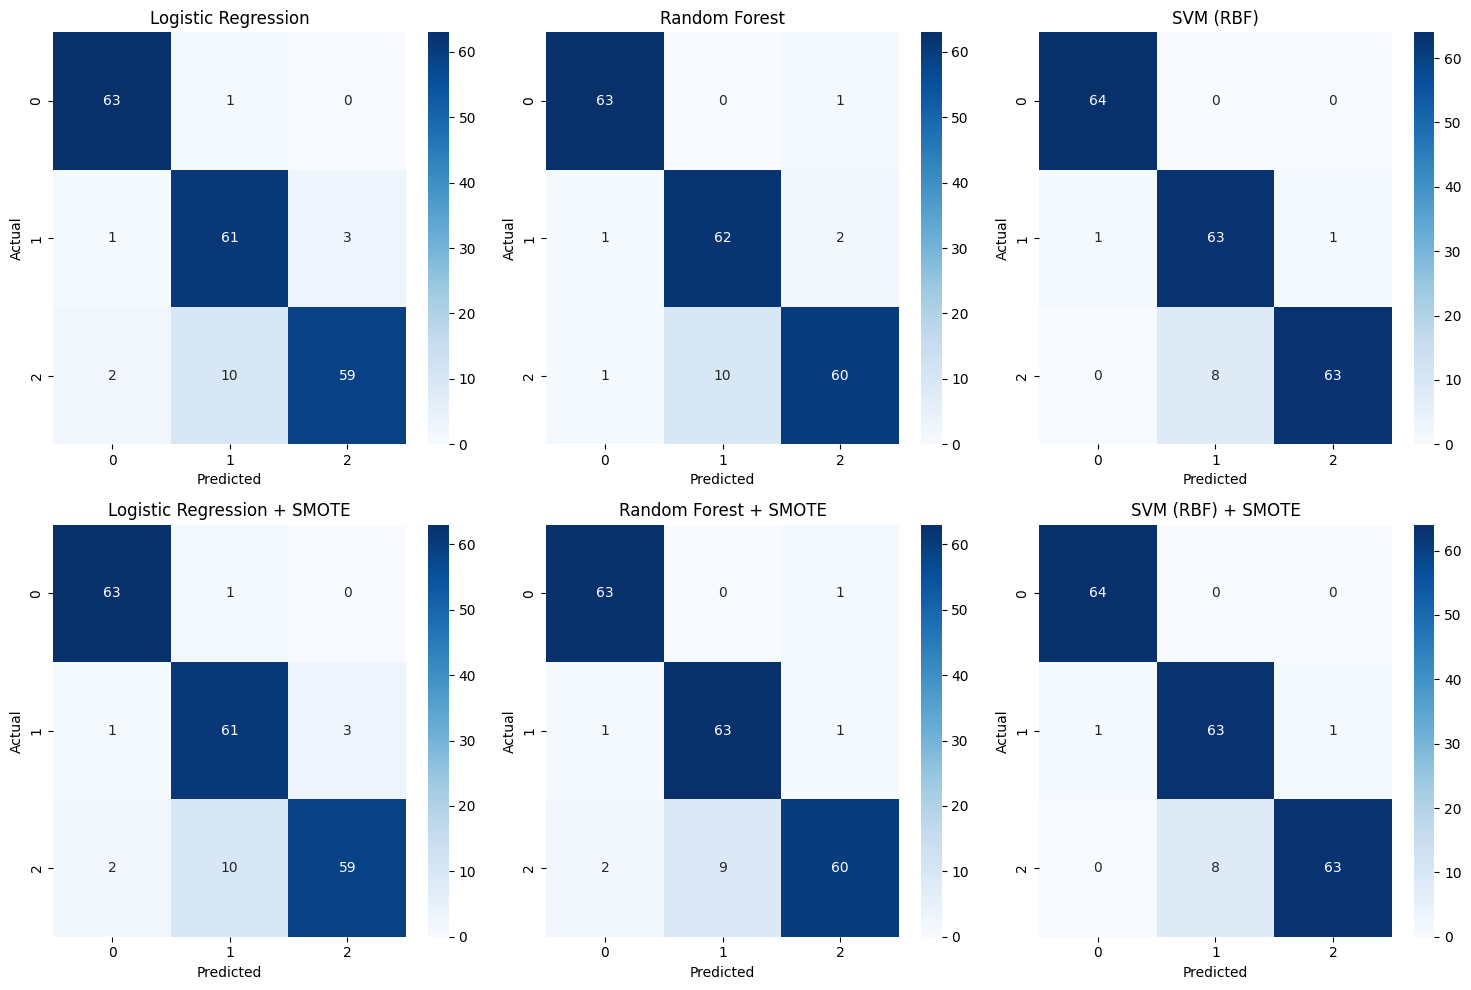


Logistic Regression: OVR vs Multinomial
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
        LogReg (OVR)     0.900   0.900874   0.900  0.899512 0.967795
LogReg (Multinomial)     0.915   0.918624   0.915  0.914532 0.974876

With More Overlapping Classes (class_sep=0.5):
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.565   0.600287   0.565  0.573985 0.711077
      Random Forest     0.815   0.820465   0.815  0.815457 0.956097
          SVM (RBF)     0.795   0.801574   0.795  0.795676 0.930565


In [26]:
from sklearn.multiclass import OneVsRestClassifier

class MultiClassComparison:
    """
    Compare Logistic Regression, Random Forest, and SVM on multi-class classification.
    Includes SMOTE balancing, performance metrics, and overlap analysis.
    """
    
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.X_train_smote = None
        self.y_train_smote = None
        self.models = {}
        self.models_smote = {}
        self.results = []
        self.overlap_results = []
    
    # -------------------------------------------------------------------------
    # Data Generation
    # -------------------------------------------------------------------------
    def load_data(self):
        """Generate multi-class dataset and split."""
        X, y = make_classification(n_samples=1000, n_features=10, n_classes=3,
                                   n_clusters_per_class=1, n_informative=8,
                                   n_redundant=2, random_state=42)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        if self.verbose:
            print(f"Original class distribution: {np.bincount(self.y_train)}")
    
    # -------------------------------------------------------------------------
    # SMOTE Balancing
    # -------------------------------------------------------------------------
    def apply_smote(self):
        """Apply SMOTE for class balancing."""
        smote = SMOTE(random_state=42)
        self.X_train_smote, self.y_train_smote = smote.fit_resample(self.X_train, self.y_train)
        if self.verbose:
            print(f"After SMOTE: {np.bincount(self.y_train_smote)}")
    
    # -------------------------------------------------------------------------
    # Model Training
    # -------------------------------------------------------------------------
    def train_models(self):
        """Train LR, RF, SVM with and without SMOTE."""
        model_configs = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
        }
        
        for name, model in model_configs.items():
            self.models[name] = model.__class__(**model.get_params()).fit(self.X_train, self.y_train)
            self.models_smote[name] = model.__class__(**model.get_params()).fit(self.X_train_smote, self.y_train_smote)
    
    # -------------------------------------------------------------------------
    # Performance Analysis
    # -------------------------------------------------------------------------
    def evaluate_model(self, model, X_test, y_test, name):
        """Compute accuracy, precision, recall, F1, ROC-AUC."""
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)
        
        return {
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted'),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'F1-Score': f1_score(y_test, y_pred, average='weighted'),
            'ROC-AUC': roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        }
    
    def performance_analysis(self):
        """Evaluate all models and display results."""
        self.results = []
        for name, model in self.models.items():
            self.results.append(self.evaluate_model(model, self.X_test, self.y_test, name))
        for name, model in self.models_smote.items():
            self.results.append(self.evaluate_model(model, self.X_test, self.y_test, f'{name} + SMOTE'))
        
        results_df = pd.DataFrame(self.results)
        if self.verbose:
            print("\nModel Comparison:")
            print(results_df.to_string(index=False))
        return results_df
    
    # -------------------------------------------------------------------------
    # Confusion Matrix Visualization
    # -------------------------------------------------------------------------
    def plot_confusion_matrices(self):
        """Plot confusion matrices for all models."""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        all_models = [(n, m) for n, m in self.models.items()] + [(f'{n} + SMOTE', m) for n, m in self.models_smote.items()]
        
        for ax, (name, model) in zip(axes.flatten(), all_models):
            y_pred = model.predict(self.X_test)
            cm = confusion_matrix(self.y_test, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
            ax.set_title(name)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
        
        plt.tight_layout()
        plt.show()
    
    # -------------------------------------------------------------------------
    # OVR vs Default (Multinomial) Comparison
    # -------------------------------------------------------------------------
    def compare_multiclass_strategies(self):
        """Compare OVR wrapper vs default multinomial for Logistic Regression."""
        # OVR using explicit wrapper
        log_reg_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
        log_reg_ovr.fit(self.X_train, self.y_train)
        
        # Default (multinomial with lbfgs solver)
        log_reg_default = LogisticRegression(max_iter=1000, random_state=42)
        log_reg_default.fit(self.X_train, self.y_train)
        
        ovr_results = self.evaluate_model(log_reg_ovr, self.X_test, self.y_test, 'LogReg (OVR)')
        default_results = self.evaluate_model(log_reg_default, self.X_test, self.y_test, 'LogReg (Multinomial)')
        
        if self.verbose:
            print("\nLogistic Regression: OVR vs Multinomial")
            print(pd.DataFrame([ovr_results, default_results]).to_string(index=False))
    
    # -------------------------------------------------------------------------
    # Overlapping Classes Test
    # -------------------------------------------------------------------------
    def test_overlapping_classes(self):
        """Test models on dataset with more class overlap."""
        X_overlap, y_overlap = make_classification(
            n_samples=1000, n_features=10, n_classes=3,
            n_clusters_per_class=1, n_informative=4,
            class_sep=0.5, random_state=42
        )
        X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
            X_overlap, y_overlap, test_size=0.2, random_state=42
        )
        
        overlap_models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
        }
        
        self.overlap_results = []
        for name, model in overlap_models.items():
            model.fit(X_train_o, y_train_o)
            self.overlap_results.append(self.evaluate_model(model, X_test_o, y_test_o, name))
        
        if self.verbose:
            print("\nWith More Overlapping Classes (class_sep=0.5):")
            print(pd.DataFrame(self.overlap_results).to_string(index=False))
    
    # -------------------------------------------------------------------------
    # Pipeline
    # -------------------------------------------------------------------------
    def pipeline(self):
        """Run full analysis."""
        self.load_data()
        self.apply_smote()
        self.train_models()
        self.performance_analysis()
        self.plot_confusion_matrices()
        self.compare_multiclass_strategies()
        self.test_overlapping_classes()


# Run the pipeline
mcc = MultiClassComparison(verbose=True)
mcc.pipeline()

## Reflection
1. Which model performs best overall? Compare using F1-score and ROC-AUC.

SVM (RBF) performs best overall with the highest F1-score (0.950) and ROC-AUC (0.996). It handles the multi-class problem well because the RBF kernel can create flexible non-linear decision boundaries. Random Forest also performs competitively (F1=0.925, ROC-AUC=0.988), while Logistic Regression lags slightly behind (F1=0.915, ROC-AUC=0.975).

2. How does SMOTE affect classification performance? Would balancing the dataset improve certain metrics?

SMOTE generates synthetic samples for minority classes to balance the dataset. In this case the classes were already nearly balanced (268/267/265), so SMOTE doesn't change performance that much, in fact SVM and Logical Regression had no change to their F1 scores. When you have imbalanced classes, SMOTE typically has a bigger impact with the tradeoff that precision might drop slightly because the synthetic samples aren't perfectly representative of real data.

3. If this were a business decision-making tool, should we prioritize Precision or Recall? Why?

If high-value customer are way more value than low-value, then prioritize Recall to make sure you catch all high-value customers even if some mid-value ones slip in. If resources for high-value treatment are limited or you just higher overall targeting across all classes, prioritize Precision to avoid wasting the wrong resources on misclassified customers.

4. Try switching the multi-class classification setting in Logistic Regression. How does the performance change?

For this dataset, multinomial performs better (F1=0.915, ROC-AUC=0.975) compared to OVR (F1=0.900, ROC-AUC=0.968). Multinomial tends to be slightly better when classes are mutually exclusive and the data is well-behaved, while OVR can be more robust when classes have very different characteristics.

5. Modify the dataset to have more overlapping classes. Which model handles this situation better?

With more overlapping classes (class_sep=0.5), Random Forest performs the best (F1=0.815, ROC-AUC=0.956). It handles overlap better than even SVM RBF. Logistic Regression struggles the most (F1=0.574, ROC-AUC=0.711) because linear boundaries can't cleanly separate overlapping classes.